# Wine Quality Comparative Study
### Logistic Regression vs Random Forest — Red & White Wine Datasets
**Author:** Mani | PGDSAI3

This notebook compares Logistic Regression and Random Forest classifiers on the
UCI Wine Quality datasets (red and white variants), predicting wine `quality`
from physicochemical properties.


## Task 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

%matplotlib inline
plt.rcParams['figure.figsize'] = (6, 5)


## Task 2: Load the Datasets

In [2]:
red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')

print("Red wine dataset shape:", red.shape)
print("White wine dataset shape:", white.shape)
red.head()


Red wine dataset shape: (1599, 12)
White wine dataset shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Task 3: Exploratory Data Analysis

In [3]:
print("Red wine - quality distribution:")
print(red['quality'].value_counts().sort_index())
print()
print("White wine - quality distribution:")
print(white['quality'].value_counts().sort_index())


Red wine - quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

White wine - quality distribution:
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


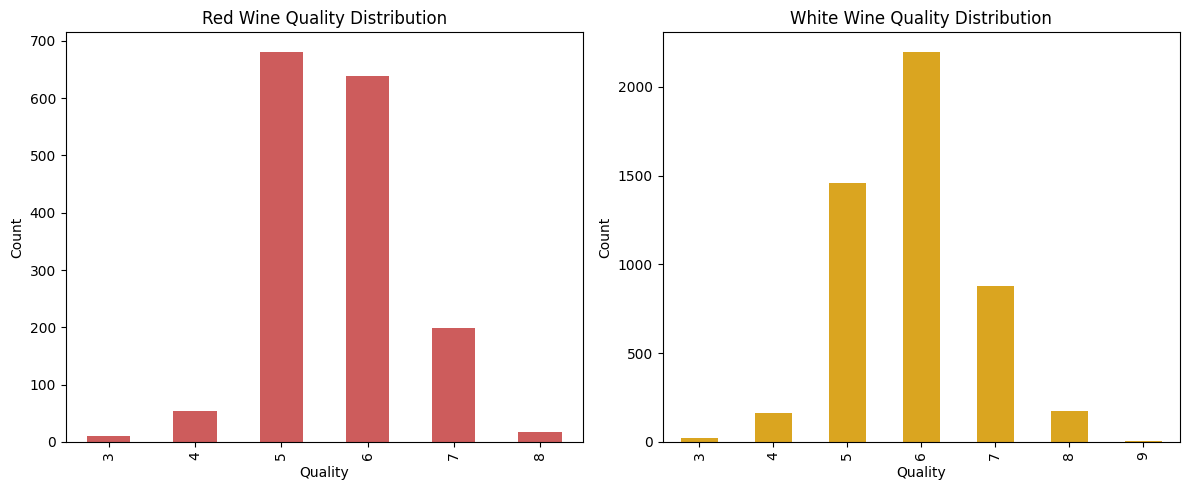

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
red['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='indianred')
axes[0].set_title('Red Wine Quality Distribution')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')

white['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='goldenrod')
axes[1].set_title('White Wine Quality Distribution')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [5]:
print("Red wine - missing values:")
print(red.isnull().sum().sum())
print()
print("White wine - missing values:")
print(white.isnull().sum().sum())
print()
print("Red wine - summary statistics:")
red.describe()


Red wine - missing values:
0

White wine - missing values:
0

Red wine - summary statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Task 4: Train/Test Split & Preprocessing

In [6]:
def prepare_data(df):
    X = df.drop(columns=['quality'])
    y = df['quality']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

Xr_train, Xr_test, yr_train, yr_test = prepare_data(red)
Xw_train, Xw_test, yw_train, yw_test = prepare_data(white)

print("Red   - train:", Xr_train.shape, "test:", Xr_test.shape)
print("White - train:", Xw_train.shape, "test:", Xw_test.shape)


Red   - train: (1279, 11) test: (320, 11)
White - train: (3918, 11) test: (980, 11)


## Task 5: Train Models — Logistic Regression & Random Forest

In [7]:
def train_and_evaluate(X_train, X_test, y_train, y_test, name):
    results = {}

    # Logistic Regression (scaled)
    lr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=5000))
    ])
    lr_pipe.fit(X_train, y_train)
    lr_pred = lr_pipe.predict(X_test)
    lr_acc = accuracy_score(y_test, lr_pred)
    lr_f1 = f1_score(y_test, lr_pred, average='macro')

    print(f"=== {name} — Logistic Regression ===")
    print(f"Accuracy: {lr_acc:.4f}  |  Macro F1: {lr_f1:.4f}")
    print(classification_report(y_test, lr_pred, zero_division=0))

    results['Logistic Regression'] = {
        'accuracy': lr_acc, 'f1_macro': lr_f1,
        'pred': lr_pred, 'cm': confusion_matrix(y_test, lr_pred)
    }

    # Random Forest
    rf = RandomForestClassifier(n_estimators=300, random_state=42)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_acc = accuracy_score(y_test, rf_pred)
    rf_f1 = f1_score(y_test, rf_pred, average='macro')

    print(f"=== {name} — Random Forest ===")
    print(f"Accuracy: {rf_acc:.4f}  |  Macro F1: {rf_f1:.4f}")
    print(classification_report(y_test, rf_pred, zero_division=0))

    results['Random Forest'] = {
        'accuracy': rf_acc, 'f1_macro': rf_f1,
        'pred': rf_pred, 'cm': confusion_matrix(y_test, rf_pred)
    }

    return results

red_results = train_and_evaluate(Xr_train, Xr_test, yr_train, yr_test, "Red Wine")


=== Red Wine — Logistic Regression ===
Accuracy: 0.5906  |  Macro F1: 0.2776
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320



=== Red Wine — Random Forest ===
Accuracy: 0.6813  |  Macro F1: 0.4094
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320



In [8]:
white_results = train_and_evaluate(Xw_train, Xw_test, yw_train, yw_test, "White Wine")


=== White Wine — Logistic Regression ===
Accuracy: 0.5490  |  Macro F1: 0.2367
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
           6       0.53      0.76      0.63       440
           7       0.56      0.27      0.37       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.55       980
   macro avg       0.31      0.23      0.24       980
weighted avg       0.53      0.55      0.52       980



=== White Wine — Random Forest ===
Accuracy: 0.6724  |  Macro F1: 0.4222
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.64      0.82      0.72       440
           7       0.71      0.49      0.58       176
           8       1.00      0.54      0.70        35
           9       0.00      0.00      0.00         1

    accuracy                           0.67       980
   macro avg       0.52      0.38      0.42       980
weighted avg       0.68      0.67      0.66       980



## Task 6: Confusion Matrices

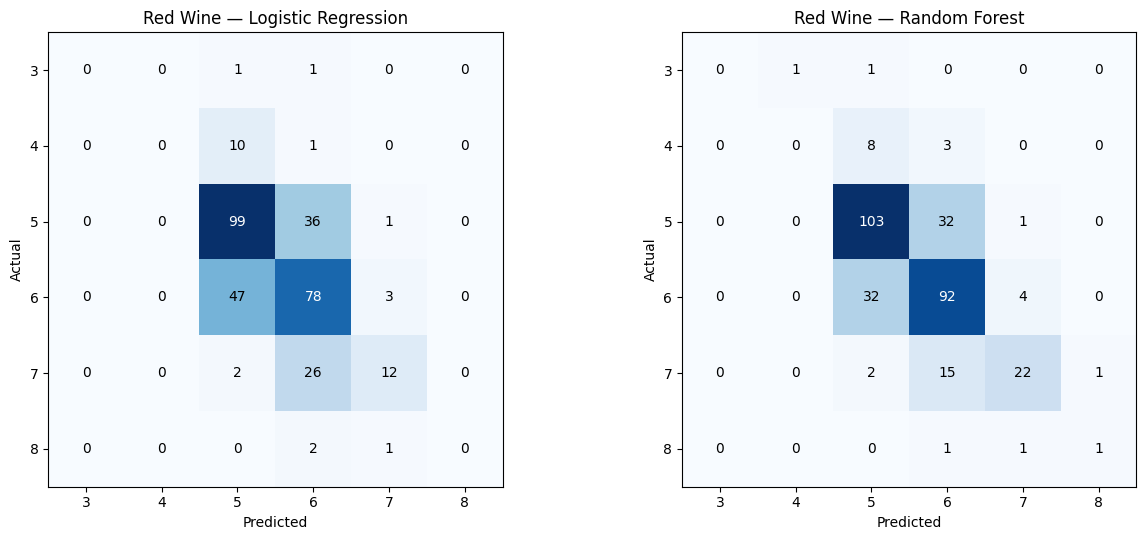

In [9]:
def plot_cm(cm, labels, title, ax):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

red_labels = sorted(yr_test.unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_cm(red_results['Logistic Regression']['cm'], red_labels, 'Red Wine — Logistic Regression', axes[0])
plot_cm(red_results['Random Forest']['cm'], red_labels, 'Red Wine — Random Forest', axes[1])
plt.tight_layout()
plt.show()


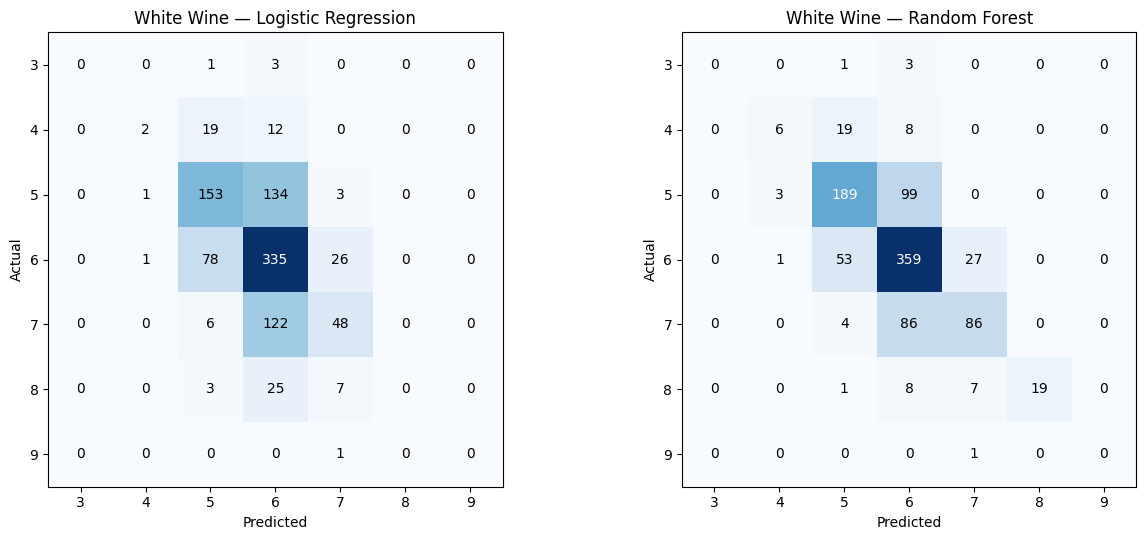

In [10]:
white_labels = sorted(yw_test.unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_cm(white_results['Logistic Regression']['cm'], white_labels, 'White Wine — Logistic Regression', axes[0])
plot_cm(white_results['Random Forest']['cm'], white_labels, 'White Wine — Random Forest', axes[1])
plt.tight_layout()
plt.show()


## Task 7: Comparative Summary & Conclusion

In [11]:
summary = pd.DataFrame([
    {'Dataset': 'Red',   'Model': 'Logistic Regression', 'Accuracy': red_results['Logistic Regression']['accuracy'],   'Macro F1': red_results['Logistic Regression']['f1_macro']},
    {'Dataset': 'Red',   'Model': 'Random Forest',        'Accuracy': red_results['Random Forest']['accuracy'],        'Macro F1': red_results['Random Forest']['f1_macro']},
    {'Dataset': 'White', 'Model': 'Logistic Regression', 'Accuracy': white_results['Logistic Regression']['accuracy'], 'Macro F1': white_results['Logistic Regression']['f1_macro']},
    {'Dataset': 'White', 'Model': 'Random Forest',        'Accuracy': white_results['Random Forest']['accuracy'],      'Macro F1': white_results['Random Forest']['f1_macro']},
])
summary['Accuracy'] = summary['Accuracy'].round(4)
summary['Macro F1'] = summary['Macro F1'].round(4)
summary


,Dataset,Model,Accuracy,Macro F1
0,Red,Logistic Regression,0.5906,0.2776
1,Red,Random Forest,0.6812,0.4094
2,White,Logistic Regression,0.5490,0.2367
3,White,Random Forest,0.6724,0.4222


### Conclusion

- **Random Forest outperforms Logistic Regression** on both the red and white wine
  datasets, on both accuracy and macro F1.
- Logistic Regression struggles most with the **macro F1 score**, since it doesn't
  handle the class imbalance in the `quality` label well — minority classes
  (3, 4, 8, 9) get almost no correct predictions.
- Random Forest handles non-linear feature interactions and imbalanced classes
  better, giving a meaningfully higher macro F1 on both datasets.
- Across both models, the **extreme quality classes (3, 4, 8, 9)** are the hardest
  to predict correctly, due to very low sample counts and heavy overlap with the
  dominant middle classes (5 and 6).
- **Next step for improvement:** using `class_weight='balanced'` in both models,
  or applying resampling techniques (e.g. SMOTE) to address the class imbalance
  and improve minority-class recall.
